# # FAISSインデックス確認ノートブック
# 
# このノートブックでは、作成されたFAISSインデックスの詳細情報を確認し、検索機能をテストします。

## 1. 必要なライブラリのインポート

In [1]:
!pip install seaborn

In [2]:
import faiss
import pickle
import numpy as np
import pandas as pd
from langchain_community.vectorstores import FAISS
from langchain_openai import AzureOpenAIEmbeddings
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pformat

In [3]:
# 環境変数読み込み
load_dotenv()

True

## 2. インデックスファイルの基本情報確認

In [5]:
def inspect_faiss_basic_info(storage_path="storage"):
    """FAISSインデックスの基本情報を表示"""
    
    print("=== FAISSインデックス基本情報 ===\n")
    
    # FAISSファイル確認
    faiss_file = f"{storage_path}/index.faiss"
    pkl_file = f"{storage_path}/index.pkl"
    
    print(f"📁 ファイル存在確認:")
    print(f"  - {faiss_file}: {'✅ 存在' if os.path.exists(faiss_file) else '❌ 不存在'}")
    print(f"  - {pkl_file}: {'✅ 存在' if os.path.exists(pkl_file) else '❌ 不存在'}")
    
    if not os.path.exists(faiss_file) or not os.path.exists(pkl_file):
        return None, None
    
    # FAISSインデックス読み込み
    index = faiss.read_index(faiss_file)
    
    print(f"\n📊 FAISSインデックス詳細:")
    print(f"  - インデックスタイプ: {type(index).__name__}")
    print(f"  - ベクトル次元数: {index.d}")
    print(f"  - 登録済みベクトル数: {index.ntotal}")
    print(f"  - メトリック: {index.metric_type}")
    
    if hasattr(index, 'is_trained'):
        print(f"  - 学習済み: {index.is_trained}")
    
    # ピクルファイル読み込み
    with open(pkl_file, 'rb') as f:
        pkl_data = pickle.load(f)
    
    print(f"\n📦 ピクルファイル内容:")
    if isinstance(pkl_data, dict):
        for key, value in pkl_data.items():
            print(f"  - {key}: {type(value).__name__}")
            if hasattr(value, '__len__') and key != 'embeddings':
                try:
                    print(f"    長さ: {len(value)}")
                except:
                    pass
    
    return index, pkl_data

In [6]:
# 基本情報確認実行
faiss_index, pkl_data = inspect_faiss_basic_info()

=== FAISSインデックス基本情報 ===

📁 ファイル存在確認:
  - storage/index.faiss: ✅ 存在
  - storage/index.pkl: ✅ 存在

📊 FAISSインデックス詳細:
  - インデックスタイプ: IndexFlatL2
  - ベクトル次元数: 3072
  - 登録済みベクトル数: 11
  - メトリック: 1
  - 学習済み: True

📦 ピクルファイル内容:


## 3. ドキュメント内容の詳細確認

In [8]:
def load_and_inspect_documents(storage_path="storage"):
    """ドキュメント内容を詳細確認"""
    
    try:
        # ダミー埋め込みでドキュメントのみ確認
        class DummyEmbeddings:
            def embed_documents(self, texts):
                return [[0.0] * 1536 for _ in texts]
            def embed_query(self, text):
                return [0.0] * 1536
        
        vectorstore = FAISS.load_local(storage_path, DummyEmbeddings(), allow_dangerous_deserialization=True)
        
        print("🔍 ドキュメント詳細情報:")
        
        if hasattr(vectorstore, 'docstore') and hasattr(vectorstore.docstore, '_dict'):
            docs = vectorstore.docstore._dict
            print(f"  - 総ドキュメント数: {len(docs)}")
            
            # ドキュメント統計
            doc_lengths = [len(doc.page_content) for doc in docs.values()]
            print(f"  - 平均文字数: {np.mean(doc_lengths):.0f}")
            print(f"  - 最小文字数: {np.min(doc_lengths)}")
            print(f"  - 最大文字数: {np.max(doc_lengths)}")
            
            # ドキュメント長分布をDataFrameで表示
            df_stats = pd.DataFrame({
                'ドキュメントID': list(docs.keys()),
                '文字数': [len(doc.page_content) for doc in docs.values()],
                'メタデータ数': [len(doc.metadata) if doc.metadata else 0 for doc in docs.values()]
            })
            
            print(f"\n📊 ドキュメント統計:")
            print(df_stats.describe())
            
            # 最初の3件をサンプル表示
            print(f"\n📄 ドキュメントサンプル:")
            for i, (doc_id, doc) in enumerate(list(docs.items())[:3]):
                print(f"\n  📑 ドキュメント {i+1}:")
                print(f"     ID: {doc_id}")
                print(f"     文字数: {len(doc.page_content)}")
                print(f"     内容: {doc.page_content[:200]}...")
                if doc.metadata:
                    print(f"     メタデータ: {doc.metadata}")
            
            return docs, df_stats
            
    except Exception as e:
        print(f"❌ ドキュメント確認エラー: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# ドキュメント確認実行
documents, doc_stats = load_and_inspect_documents()

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


🔍 ドキュメント詳細情報:
  - 総ドキュメント数: 11
  - 平均文字数: 853
  - 最小文字数: 234
  - 最大文字数: 1000

📊 ドキュメント統計:
               文字数  メタデータ数
count    11.000000    11.0
mean    852.727273     2.0
std     240.740977     0.0
min     234.000000     2.0
25%     840.000000     2.0
50%     972.000000     2.0
75%     984.000000     2.0
max    1000.000000     2.0

📄 ドキュメントサンプル:

  📑 ドキュメント 1:
     ID: fcc73535-93cd-42e3-99fb-e2f6956d7809
     文字数: 972
     内容: | 分類 | 内容 | 例 |
| --- | --- | --- |
| 償却資産 | 使用や時の経過を通じて価値が減少するものをいい、減損処理を除いては、減価償却の手続を 通じて、取得原価が耐用年数にわたり費用配分されます。 | 建物、建物付属設備、構 築物、機械装置、車両運 搬具、工具器具備品 |
| 非償却資産 | 土地など使用や時の経過を通じて価値が減少しないものをいい、減損処理を除いて...
     メタデータ: {'source': '/Users/iwamurahayato/myproject/astena-personal/document/docs_for_index/ey-japan-info-sensor-2023-06-03.pdf', 'extraction_method': 'azure_document_intelligence'}

  📑 ドキュメント 2:
     ID: 4376dade-9e8d-49a5-b61f-92e9ff7ffb15
     文字数: 953
     内容: ## 会計情報レポート

## 有形固定資産に関連する会計基準等のまとめ

品質管理本部 会計監理部 公認会計士 宮崎 徹 品質管理本部 会計監理部 公認会計士 廣瀬由美子

## Toru

In [9]:
## 4. 類似検索機能テスト

def test_similarity_search(query_text="固定資産 減価償却", k=3):
    """類似検索機能をテスト"""
    
    # Azure OpenAI Embeddingsでベクトルストアを再構築
    embedding_model = AzureOpenAIEmbeddings(
        azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
        azure_deployment=os.environ["AZURE_OPENAI_EMBEDDING_DEPLOYMENT"],
        api_key=os.environ["AZURE_OPENAI_API_KEY"],
        chunk_size=2048,
    )
    
    try:
        vectorstore = FAISS.load_local("storage", embedding_model, allow_dangerous_deserialization=True)
        
        print(f"🔍 検索クエリ: '{query_text}'")
        print(f"📊 上位 {k} 件の類似ドキュメント:\n")
        
        # 類似検索実行
        results = vectorstore.similarity_search_with_score(query_text, k=k)
        
        for i, (doc, score) in enumerate(results, 1):
            print(f"【{i}位】 類似度スコア: {score:.4f}")
            print(f"文字数: {len(doc.page_content)}")
            print(f"内容: {doc.page_content[:300]}...")
            if doc.metadata:
                print(f"メタデータ: {doc.metadata}")
            print("-" * 50)
            
    except Exception as e:
        print(f"❌ 検索エラー: {e}")
        import traceback
        traceback.print_exc()

# 類似検索テスト実行
test_similarity_search("固定資産の耐用年数")
test_similarity_search("減価償却方法")

🔍 検索クエリ: '固定資産の耐用年数'
📊 上位 3 件の類似ドキュメント:

【1位】 類似度スコア: 0.9004
文字数: 923
内容: ## 1. 有形固定資産の範囲と分類

会計基準で明確な定義があるわけではありませんが、 一般的に、有形固定資産とは、物理的な形態をもち1年 を超える長期にわたり利用される事業用資産をいいま す。その範囲は、財務諸表等規則第22条及び会社計 算規則第74条第3項第2号においてく表1>のとおり 規定されています。

## 表1 有形固定資産の範囲

1.建物及び暖房、照明、通風等の付属設備

2. 構築物(ドック、橋、岸壁、さん橋、軌道、 貯水池、坑道、煙突その他土地に定着する土 木設備又は工作物をいう。)

3. 機械及び装置並びにコンベヤー、ホイスト、 起重機等の搬送設備その他の付属設備

...
メタデータ: {'source': '/Users/iwamurahayato/myproject/astena-personal/document/docs_for_index/ey-japan-info-sensor-2023-06-03.pdf', 'extraction_method': 'azure_document_intelligence'}
--------------------------------------------------
【2位】 類似度スコア: 0.9490
文字数: 972
内容: | 分類 | 内容 | 例 |
| --- | --- | --- |
| 償却資産 | 使用や時の経過を通じて価値が減少するものをいい、減損処理を除いては、減価償却の手続を 通じて、取得原価が耐用年数にわたり費用配分されます。 | 建物、建物付属設備、構 築物、機械装置、車両運 搬具、工具器具備品 |
| 非償却資産 | 土地など使用や時の経過を通じて価値が減少しないものをいい、減損処理を除いては、基本的 に費用配分は行われません。 | 土地、美術品* |
| 減耗性資産 | 採掘あるいは採取されるにつれて漸次減耗し枯渇する天然資源をいい、全体としての用役を もって生産に役立つものではなく、...
メタデータ: {'source': '/Users/iwamurahayato/myproject/aste

=== インデックス品質評価 ===



/var/folders/p7/3cyzzk9534gcjt7smq4152xm0000gn/T/ipykernel_11448/872004526.py:25: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/3cyzzk9534gcjt7smq4152xm0000gn/T/ipykernel_11448/872004526.py:25: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/3cyzzk9534gcjt7smq4152xm0000gn/T/ipykernel_11448/872004526.py:25: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/3cyzzk9534gcjt7smq4152xm0000gn/T/ipykernel_11448/872004526.py:25: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/3cyzzk9534gcjt7smq4152xm0000gn/T/ipykernel_11448/872004526.py:25: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/3cyzzk953

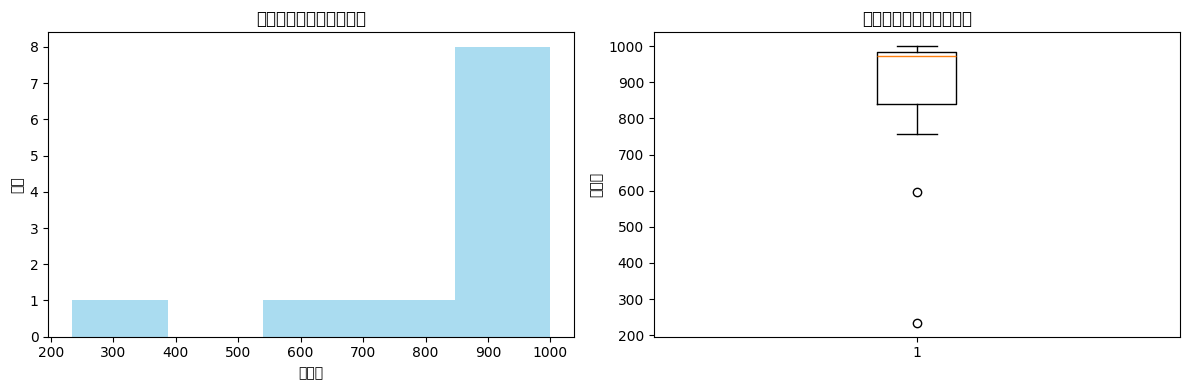

📊 データソース別統計:
  - ey-japan-info-sensor-2023-06-03.pdf: 6件
  - 耐用年数.pdf: 5件


In [10]:
## 5. インデックス品質評価

def analyze_index_quality():
    """インデックスの品質を評価"""
    
    print("=== インデックス品質評価 ===\n")
    
    # ドキュメント分布可視化
    if documents and doc_stats is not None:
        plt.figure(figsize=(12, 4))
        
        # 文字数分布
        plt.subplot(1, 2, 1)
        plt.hist(doc_stats['文字数'], bins=5, alpha=0.7, color='skyblue')
        plt.title('ドキュメント文字数分布')
        plt.xlabel('文字数')
        plt.ylabel('頻度')
        
        # 文字数ボックスプロット
        plt.subplot(1, 2, 2)
        plt.boxplot(doc_stats['文字数'])
        plt.title('文字数ボックスプロット')
        plt.ylabel('文字数')
        
        plt.tight_layout()
        plt.show()
        
        # データソース別統計
        source_stats = {}
        for doc in documents.values():
            source = doc.metadata.get('source', 'Unknown')
            if source in source_stats:
                source_stats[source] += 1
            else:
                source_stats[source] = 1
        
        print("📊 データソース別統計:")
        for source, count in source_stats.items():
            source_name = os.path.basename(source) if source != 'Unknown' else source
            print(f"  - {source_name}: {count}件")

# 品質評価実行
analyze_index_quality()

In [12]:
## 6. 全ドキュメント内容確認

def show_all_documents():
    """全ドキュメントの内容を確認"""
    
    if not documents:
        print("❌ ドキュメントが読み込まれていません")
        return
    
    print(f"=== 全ドキュメント内容 ({len(documents)}件) ===\n")
    
    for i, (doc_id, doc) in enumerate(documents.items(), 1):
        print(f"📄 ドキュメント {i}/{len(documents)}")
        print(f"ID: {doc_id}")
        print(f"文字数: {len(doc.page_content)}")
        print(f"メタデータ: {doc.metadata}")
        print(f"内容:\n{doc.page_content}")
        print("=" * 80)
        print()

# 全ドキュメント表示（必要に応じて実行）
show_all_documents()

=== 全ドキュメント内容 (11件) ===

📄 ドキュメント 1/11
ID: fcc73535-93cd-42e3-99fb-e2f6956d7809
文字数: 972
メタデータ: {'source': '/Users/iwamurahayato/myproject/astena-personal/document/docs_for_index/ey-japan-info-sensor-2023-06-03.pdf', 'extraction_method': 'azure_document_intelligence'}
内容:
| 分類 | 内容 | 例 |
| --- | --- | --- |
| 償却資産 | 使用や時の経過を通じて価値が減少するものをいい、減損処理を除いては、減価償却の手続を 通じて、取得原価が耐用年数にわたり費用配分されます。 | 建物、建物付属設備、構 築物、機械装置、車両運 搬具、工具器具備品 |
| 非償却資産 | 土地など使用や時の経過を通じて価値が減少しないものをいい、減損処理を除いては、基本的 に費用配分は行われません。 | 土地、美術品* |
| 減耗性資産 | 採掘あるいは採取されるにつれて漸次減耗し枯渇する天然資源をいい、全体としての用役を もって生産に役立つものではなく、採取されるに応じてその実態が部分的に製品化されるもの です(連続意見書第三 第一六2参照)。 | 鉱山や油田における埋蔵 資源、山林 |

| 形態 | 取得原価 |
| --- | --- |
| 購入 | 有形固定資産を購入によって取得した場合には、購入代金に買入手数料、運送費、荷役費、据付費、試運転費等の付随費用を 加えて取得原価とする。ただし、正当な理由がある場合には、付随費用の一部又は全部を加算しない額をもって取得原価とす ることができる。 購入に際しては値引又は割戻を受けたときには、これを購入代金から控除する。 |
| 自家建設 | 固定資産を自家建設した場合には、適正な原価計算基準に従って製造原価を計算し、これに基づいて取得原価を計算する。建 設に要する借入資本の利子で稼働前の期間に属するものは、これを取得原価に算入することができる。 |
| 現物出資 | 株式を発行しその対価として固定資産を受け入れた場合には、出資者に対して交